In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.6/549.6 kB 7.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/control/rlocus.py:210: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


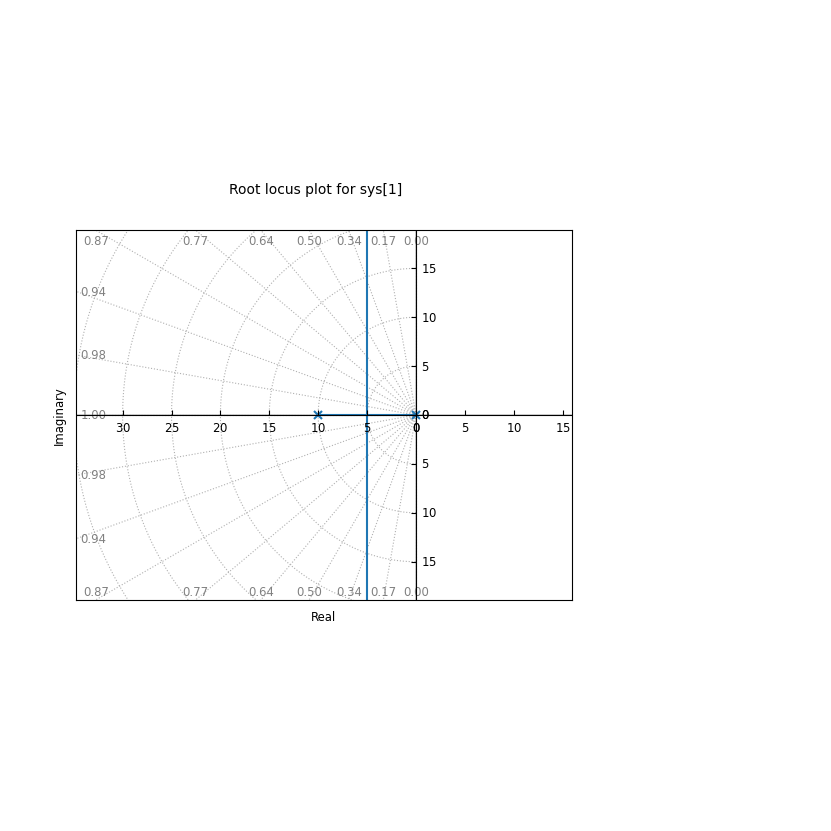

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import control as ctl
from control import TransferFunction

#função transferência
ex1 = TransferFunction (1, [1, 10, 0])
out = ctl.rlocus(ex1, xlim=None, ylim=None, plot=True, grid=None) #rlocus pede função transf da malha aberta


/usr/local/lib/python3.11/dist-packages/control/rlocus.py:210: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


1.5 s^2 - 6 s + 30
------------------
   2.5 s^2 + 38

    Eigenvalue (pole)       Damping     Frequency
        -0    +3.899j             0         3.899
         0    -3.899j            -0         3.899


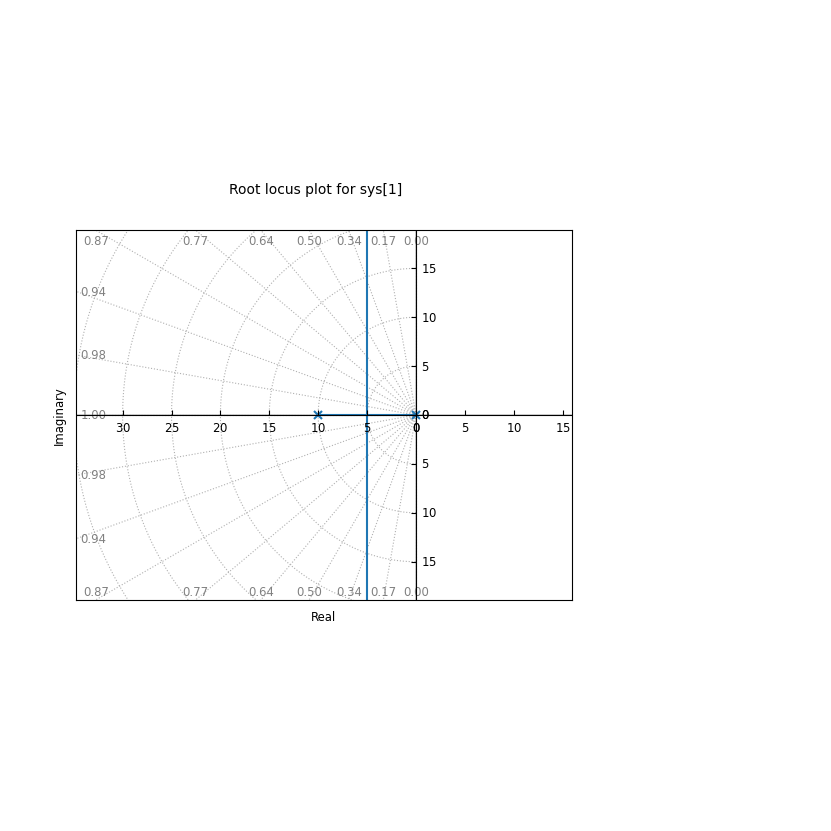

In [ ]:
#exemplo 2
#argumento da função rlocus H(s) da equação característica 1+KH(s)=0
ex2 = TransferFunction([1, -4, 20], [1, 6, 8])
out2 = ctl.rlocus(ex1, xlim=None, ylim=None, plot=True, grid=None)

k=1.5
#malha fechada sys1=linha de cima e sys2=linha de baixo da realimentação
malha_fechada = ctl.feedback(sys1 = k*ex2, sys2=1, sign=-1)
print(malha_fechada)

#dados dos polos
wn, damping, pole = ctl.damp(malha_fechada)



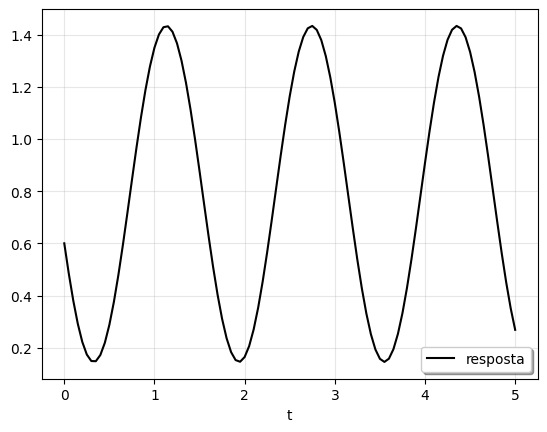

In [ ]:
t = np.linspace(0,5,101)

#resposta ao degrau unitário
tout, yout = ctl.step_response(malha_fechada, t, X0=0)

plt.plot(tout, yout, 'k', linewidth=1.5, label='resposta')
plt.legend(loc='best', shadow=True, framealpha=1)
plt.grid(alpha=0.3)
plt.xlabel('t')
plt.show()